<a href="https://colab.research.google.com/github/Nounsidev/PyTorch_Learning/blob/main/3_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step to train:

Data (prepare and load)

build model

fitting the model to data (training

making a prediction and evaluating a model (inference)

saving and loading a model

putting it all tgt

In [85]:

import torch
from torch import nn #contains all building block for neural net
import matplotlib.pyplot as plt
import numpy as np

torch.__version__

'2.11.0+cpu'

In [50]:
#1. Data
#Know param
weight = 0.7
bias = 0.3

#Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10],

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [51]:
len(X), len(y)


(50, 50)

Splitting Data into training and test sets


In [52]:
trainSplit = int(0.8 * len(X))
trainX, trainY = X[:trainSplit], y[:trainSplit]
testX, testY = X[trainSplit:], y[trainSplit:]



In [53]:
def plotPredictions(train_data = trainX,train_labels = trainY,test_data =  testX, test_labels = testY, predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  #Are there predictions
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  #Show legend
  plt.legend(prop={"size": 14});

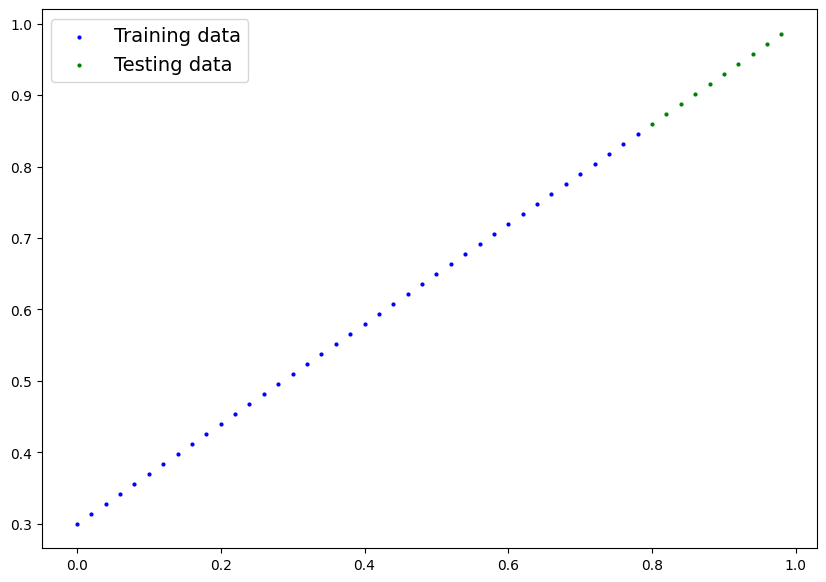

In [54]:
plotPredictions()

2. Build Model


In [55]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias



In [103]:
torch.manual_seed(42)

#Sub Class
modelZero = LinearRegressionModel()
list(modelZero.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [57]:
modelZero.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [58]:
testX, testY

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [59]:
#Making prediction
#Inference mode wont keep track of train data
with torch.inference_mode():
  yPredictions = modelZero(testX)

yPredictions

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

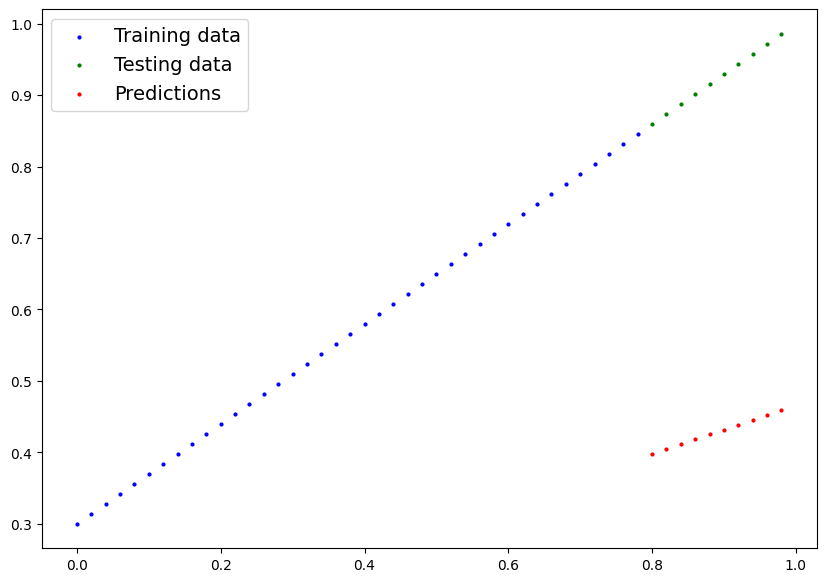

In [60]:
plotPredictions(predictions= yPredictions)

3. TRAINING MODEL


In [104]:
#Set up loss function
lossFunction = nn.L1Loss()

#Set up optimizer (stochastic gradient descent)
#lr = learning rate
optimizer = torch.optim.SGD(params=modelZero.parameters(), lr=0.001)

In [105]:
#Training Loop
epochs = 2000

#Track different values
epochCount = []
lossValues = []
testLossValues = []

for epoch in range(epochs):
  #train mode set
  modelZero.train()

  #Forward pass
  yPredictions = modelZero(trainX)

  #Calculate loss
  loss = lossFunction(yPredictions, trainY)
  #print(f"Loss: {loss}")

  #Optimized zero grad
  optimizer.zero_grad()

  #Perform backpropagation
  loss.backward()

  #Perform gradient descent
  optimizer.step()

  #turn off gradient tracking
  modelZero.eval()

  #TESTING
  with torch.inference_mode():
    testPredictions = modelZero(testX)
    testLoss = lossFunction(testPredictions, testY)

  if epoch % 10 == 0:
    epochCount.append(epoch)
    lossValues.append(loss)
    testLossValues.append(testLoss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {testLoss}")

    modelZero.state_dict()


Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.4931890368461609
Epoch: 10 | Loss: 0.3013603389263153 | Test loss: 0.4797181189060211
Epoch: 20 | Loss: 0.28983938694000244 | Test loss: 0.4662471413612366
Epoch: 30 | Loss: 0.2783183455467224 | Test loss: 0.4527761936187744
Epoch: 40 | Loss: 0.26679736375808716 | Test loss: 0.43930521607398987
Epoch: 50 | Loss: 0.2552763819694519 | Test loss: 0.4258342385292053
Epoch: 60 | Loss: 0.24375538527965546 | Test loss: 0.41236335039138794
Epoch: 70 | Loss: 0.232234388589859 | Test loss: 0.398892343044281
Epoch: 80 | Loss: 0.22071340680122375 | Test loss: 0.38542139530181885
Epoch: 90 | Loss: 0.2091923952102661 | Test loss: 0.3719504475593567
Epoch: 100 | Loss: 0.19767141342163086 | Test loss: 0.35847947001457214
Epoch: 110 | Loss: 0.18615040183067322 | Test loss: 0.34500852227211
Epoch: 120 | Loss: 0.17462942004203796 | Test loss: 0.33153754472732544
Epoch: 130 | Loss: 0.16310855746269226 | Test loss: 0.3180667459964752
Epoch: 140 | Loss: 0.

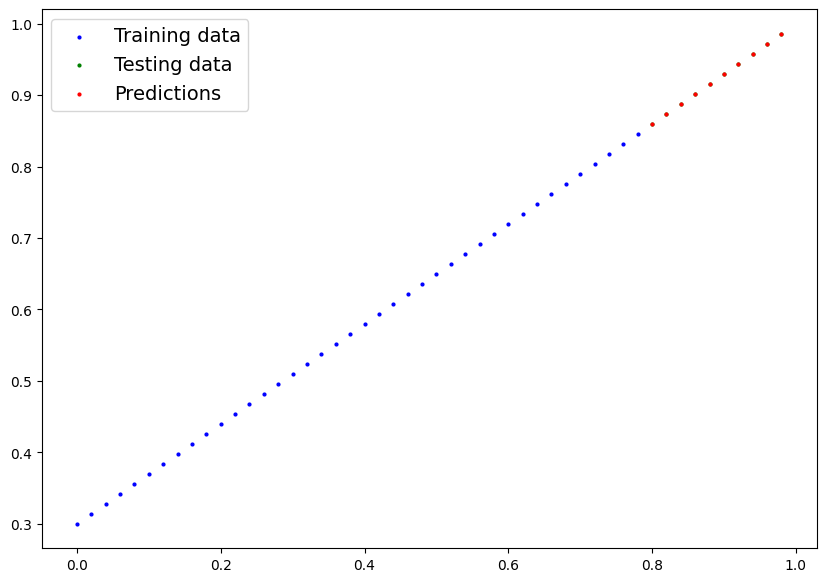

In [106]:
with torch.inference_mode():
  yPredictions = modelZero(testX)
plotPredictions(predictions= yPredictions)

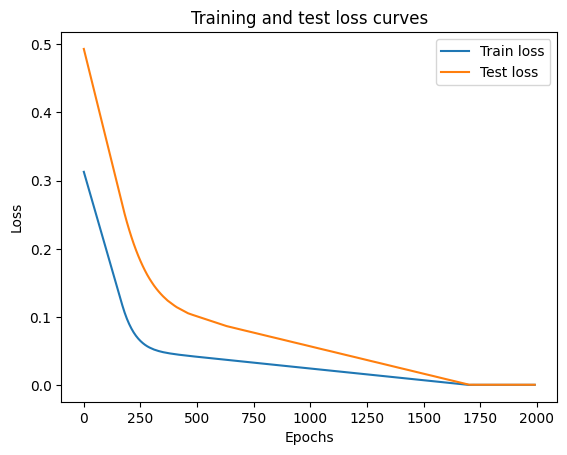

In [107]:
plt.plot(epochCount, np.array(torch.tensor(lossValues).numpy()), label="Train loss")
plt.plot(epochCount, testLossValues, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();